In [70]:
from Functions import p_lambda_ang_iso, p_lambda_ang_aniso_y, p_lambda_ang_aniso_z 
import matplotlib.pyplot as plt
from sigfig import round
import numpy as np
import pickle
import os

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

In [2]:
def load_data(dirpath):
    data = {}
    for i in range(29):
        if dirpath == "With NEW":
            filename = f"data/With EDM NEW/G2NEW_{i:02d}_withEDM.pkl"
        elif dirpath == "Without NEW":
            filename = f"data/Without EDM NEW/G2NEW_{i:02d}.pkl"
        
        phi = 2*np.pi*i/29

        with open(filename, "rb") as f:
            lam, theta, Z = pickle.load(f)

        data[i] = [lam, theta, Z, phi]
    return data

def polarisation(phi, delta):
    return [
        np.sin(phi)*np.cos(delta),
        np.sin(phi)*np.sin(delta),
        np.cos(phi)
    ]

def p(theta, lam, phi, delta, beta = -0.999417548824538):
    pol = polarisation(phi, delta)
    return p_lambda_ang_iso(lam, theta, beta) + p_lambda_ang_aniso_y(lam,theta,beta,pol[1]) + p_lambda_ang_aniso_z(lam,theta,beta,pol[2])

In [3]:
def NLL_old(deltas, data_dict):
    deltas = np.asarray(deltas)
    N = deltas.size

    total = np.zeros(N)
    per_run = {}

    for run_id, (lam, theta, Z, phi) in data_dict.items():
        p_curr = p(theta[..., None], lam[..., None], phi, deltas)
        p_safe = np.clip(p_curr, 1e-300, None)

        mask2 = (Z > 0) & np.isfinite(Z)
        Z_flat = Z.reshape(-1)
        P_flat = p_safe.reshape(-1, N)
        mask_flat = mask2.reshape(-1)

        Zk = Z_flat[mask_flat].astype(float)
        Pk = P_flat[mask_flat, :].astype(float)

        Zk /= Zk.sum()
        Pk /= Pk.sum(axis=0, keepdims=True)

        log_diff = np.log(Zk)[:, None] - np.log(Pk)
        nll_run = np.sum(log_diff**2, axis=0)

        per_run[run_id] = nll_run
        total += nll_run

    return total, per_run

state = "Without NEW"
range_dict = {"With NEW":[0,0.2],"Without NEW":[-0.1,0.1]}

data = load_data(state)
deltas = np.linspace(range_dict[state][0], range_dict[state][1], 200)
NLL_total, NLL_runs = NLL_old(deltas, data)

for d, nll in zip(deltas, NLL_total):
    print(f"NLL({d:.3g}) = {nll:.3g}")

c:\Users\JakeS\Documents\Masters Project\mphys-masters-project\Functions.py:108: RuntimeWarning: invalid value encountered in sqrt
  a1 = lambda y : np.where( tmp1(y) > tol, np.sqrt(tmp1(y)), 0)
c:\Users\JakeS\Documents\Masters Project\mphys-masters-project\Functions.py:111: RuntimeWarning: invalid value encountered in arcsin
  a2 = lambda y : np.where( np.fabs(tmp3(y)) < 1, np.arcsin( np.fabs(tmp3(y)) ), np.pi/2)
c:\Users\JakeS\Documents\Masters Project\mphys-masters-project\Functions.py:164: RuntimeWarning: invalid value encountered in arcsin
  gasin = lambda y : np.where( np.fabs(tmp3(y)) < 1, np.arcsin( np.fabs(tmp3(y)) ), np.pi/2)
c:\Users\JakeS\Documents\Masters Project\mphys-masters-project\Functions.py:159: RuntimeWarning: invalid value encountered in sqrt
  gsqrt = lambda y : np.where( tmp1(y) > tol, np.sqrt(tmp1(y)), 0)
c:\Users\JakeS\Documents\Masters Project\mphys-masters-project\Functions.py:206: RuntimeWarning: invalid value encountered in arcsin
  gasin = lambda y : np.w

NLL(-0.1) = 837
NLL(-0.099) = 821
NLL(-0.098) = 804
NLL(-0.097) = 788
NLL(-0.096) = 771
NLL(-0.095) = 755
NLL(-0.094) = 739
NLL(-0.093) = 724
NLL(-0.092) = 708
NLL(-0.091) = 693
NLL(-0.0899) = 677
NLL(-0.0889) = 662
NLL(-0.0879) = 647
NLL(-0.0869) = 633
NLL(-0.0859) = 618
NLL(-0.0849) = 604
NLL(-0.0839) = 590
NLL(-0.0829) = 576
NLL(-0.0819) = 562
NLL(-0.0809) = 548
NLL(-0.0799) = 535
NLL(-0.0789) = 521
NLL(-0.0779) = 508
NLL(-0.0769) = 495
NLL(-0.0759) = 482
NLL(-0.0749) = 469
NLL(-0.0739) = 457
NLL(-0.0729) = 445
NLL(-0.0719) = 432
NLL(-0.0709) = 420
NLL(-0.0698) = 408
NLL(-0.0688) = 397
NLL(-0.0678) = 385
NLL(-0.0668) = 374
NLL(-0.0658) = 363
NLL(-0.0648) = 352
NLL(-0.0638) = 341
NLL(-0.0628) = 330
NLL(-0.0618) = 320
NLL(-0.0608) = 310
NLL(-0.0598) = 299
NLL(-0.0588) = 289
NLL(-0.0578) = 280
NLL(-0.0568) = 270
NLL(-0.0558) = 260
NLL(-0.0548) = 251
NLL(-0.0538) = 242
NLL(-0.0528) = 233
NLL(-0.0518) = 224
NLL(-0.0508) = 216
NLL(-0.0497) = 207
NLL(-0.0487) = 199
NLL(-0.0477) = 191
NLL(-

delta_hat = 0.001 ± 0.004 NLL_min = 0.021141753250765536


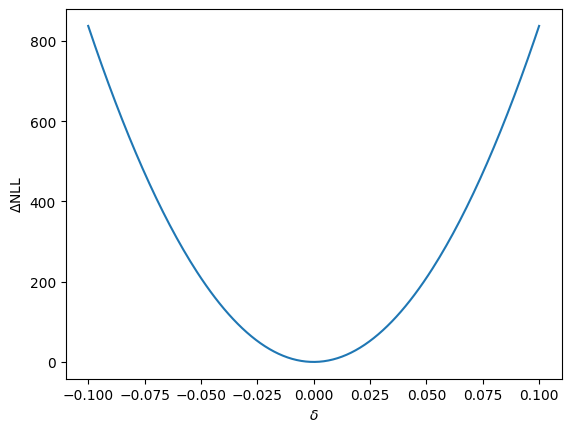

In [4]:
idx = np.argmin(NLL_total)
delta_hat = deltas[idx]
nll_min = NLL_total[idx]

deltaNLL = NLL_total - nll_min

left = deltas[(deltaNLL >= 1) & (deltas < delta_hat)].max()
right = deltas[(deltaNLL >= 1) & (deltas > delta_hat)].min()

err_minus = delta_hat - left
err_plus = right - delta_hat
err = 0.5 * (err_plus + err_minus)

print(f"delta_hat = {round(delta_hat, uncertainty = err)} NLL_min = {nll_min}")
plt.plot(deltas, deltaNLL)
plt.xlabel(r'$\delta$')
plt.ylabel(r"$\Delta$NLL")
plt.show()

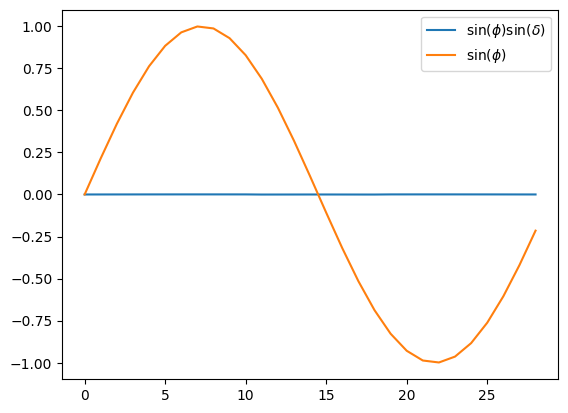

In [5]:
run_ids = np.arange(29)

NLL_idk = []
delta_idk = []

for rid in run_ids:
    nll_curve = NLL_runs[rid]
    i_min = np.argmin(nll_curve)

    NLL_idk.append(nll_curve[i_min])
    delta_idk.append(deltas[i_min])

plt.plot(run_ids, np.sin(2*np.pi*run_ids/29)*delta_idk, label=r"$\sin(\phi)\sin(\delta)$")
plt.plot(run_ids, np.sin(2*np.pi*run_ids/29), label=r"$\sin(\phi)$")
plt.legend()
plt.show()

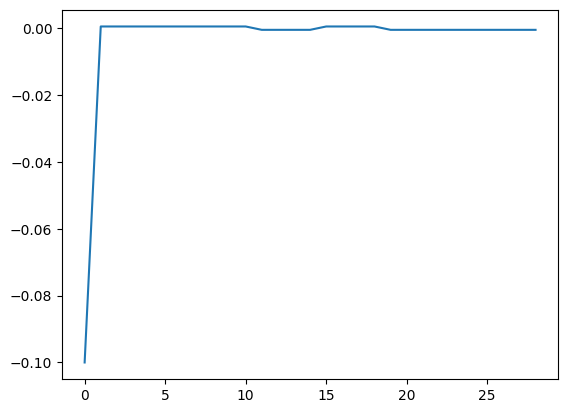

In [6]:
plt.plot(run_ids, delta_idk)
plt.show()

In [75]:
# multinomial log-likelihood
def NLL_multinomial(deltas, data_dict, N_eff=1e5, eps=1e-300):
    deltas = np.asarray(deltas)
    total = np.zeros(deltas.size)
    per_run = {}

    for run_id, (lam, theta, Z, phi) in data_dict.items():

        # ensure data PDF is finite and normalised
        Z = np.asarray(Z, dtype=float)
        Z = np.where(np.isfinite(Z) & (Z > 0), Z, 0.0)
        Z /= Z.sum()

        # model PDF for all deltas: (lam, theta, delta)
        p_curr = p(theta[..., None], lam[..., None], phi, deltas)

        # kill NaNs / negatives and avoid log(0)
        p_curr = np.where(np.isfinite(p_curr) & (p_curr > 0), p_curr, 0.0)
        p_curr = np.clip(p_curr, eps, None)

        # OPTIONAL: mask zero-data bins (recommended)
        mask = Z > 0

        # multinomial NLL per delta
        nll_run = -2 * N_eff * np.sum(
            Z[mask, None] * np.log(p_curr[mask, :]),
            axis=0
        )  # shape (ndelta,)

        per_run[run_id] = nll_run
        total += nll_run

    return total, per_run

state = "With NEW"
range_dict = {"With NEW":[0.0775,0.0825],"Without NEW":[-0.0025,0.0025]}

data = load_data(state)
deltas = np.linspace(range_dict[state][0], range_dict[state][1], 200)
NLL_total, NLL_runs = NLL_multinomial(deltas, data, N_eff=1e6)

for d, nll in zip(deltas, NLL_total):
    print(f"NLL({d:.3g}) = {nll:.3g}")

NLL(0.0775) = -1.57e+08
NLL(0.0775) = -1.57e+08
NLL(0.0776) = -1.57e+08
NLL(0.0776) = -1.57e+08
NLL(0.0776) = -1.57e+08
NLL(0.0776) = -1.57e+08
NLL(0.0777) = -1.57e+08
NLL(0.0777) = -1.57e+08
NLL(0.0777) = -1.57e+08
NLL(0.0777) = -1.57e+08
NLL(0.0778) = -1.57e+08
NLL(0.0778) = -1.57e+08
NLL(0.0778) = -1.57e+08
NLL(0.0778) = -1.57e+08
NLL(0.0779) = -1.57e+08
NLL(0.0779) = -1.57e+08
NLL(0.0779) = -1.57e+08
NLL(0.0779) = -1.57e+08
NLL(0.078) = -1.57e+08
NLL(0.078) = -1.57e+08
NLL(0.078) = -1.57e+08
NLL(0.078) = -1.57e+08
NLL(0.0781) = -1.57e+08
NLL(0.0781) = -1.57e+08
NLL(0.0781) = -1.57e+08
NLL(0.0781) = -1.57e+08
NLL(0.0782) = -1.57e+08
NLL(0.0782) = -1.57e+08
NLL(0.0782) = -1.57e+08
NLL(0.0782) = -1.57e+08
NLL(0.0783) = -1.57e+08
NLL(0.0783) = -1.57e+08
NLL(0.0783) = -1.57e+08
NLL(0.0783) = -1.57e+08
NLL(0.0784) = -1.57e+08
NLL(0.0784) = -1.57e+08
NLL(0.0784) = -1.57e+08
NLL(0.0784) = -1.57e+08
NLL(0.0785) = -1.57e+08
NLL(0.0785) = -1.57e+08
NLL(0.0785) = -1.57e+08
NLL(0.0785) = -1.57e

delta_hat = 0.0800 ± 0.0009 NLL_min = -156965844.37038106


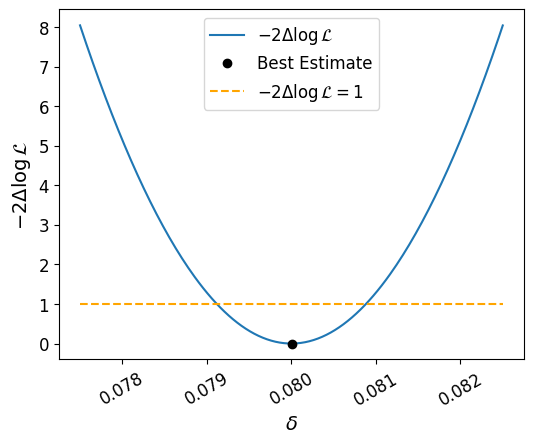

In [76]:
idx = np.argmin(NLL_total)
delta_hat = deltas[idx]
nll_min = NLL_total[idx]

deltaNLL = NLL_total - nll_min

left = deltas[(deltaNLL >= 1) & (deltas < delta_hat)].max()
right = deltas[(deltaNLL >= 1) & (deltas > delta_hat)].min()

err_minus = delta_hat - left
err_plus = right - delta_hat
err = 0.5 * (err_plus + err_minus)

print(f"delta_hat = {round(delta_hat, uncertainty = err)} NLL_min = {nll_min}")
plt.figure(figsize=(6,5))
plt.plot(deltas, deltaNLL, label=r"$-2\Delta\log\mathcal{L}$")
plt.plot(delta_hat, deltaNLL[idx], marker='o',label="Best Estimate",color="black",linestyle='')
plt.hlines(1, xmin=range_dict[state][0], xmax=range_dict[state][1],label=r"$-2\Delta\log\mathcal{L}=1$",linestyle = "--",color="orange")
plt.xlabel(r"$\delta$")
plt.subplots_adjust(bottom=0.18)
plt.ylabel(r"$-2\Delta\log\mathcal{L}$")
plt.xticks(rotation=30)
plt.legend()
plt.savefig(f"outputs/Diss Plots/NLL {state}.png")
plt.show()

In [19]:
import numpy as np

# --- settings ---
N_arr = [125, 250, 500, 1000, 2000]
deltas = np.linspace(range_dict[state][0], range_dict[state][1], 200)

eps = 1e-300
errs = []

# --- precompute S_total(delta) = sum_bins Z * log p(delta) ONCE ---
S_total = np.zeros(deltas.size, dtype=float)

for run_id, (lam, theta, Z, phi) in data.items():
    Z = np.asarray(Z, dtype=float)
    Z = np.where(np.isfinite(Z) & (Z > 0), Z, 0.0)
    Zsum = Z.sum()
    if Zsum == 0:
        continue
    Z = Z / Zsum

    # model: (lam, theta, ndelta)
    p_curr = p(theta[..., None], lam[..., None], phi, deltas)

    # sanitise model probs
    p_curr = np.asarray(p_curr, dtype=float)
    p_curr = np.where(np.isfinite(p_curr) & (p_curr > 0), p_curr, 0.0)
    p_curr = np.clip(p_curr, eps, None)

    # ignore zero-data bins to avoid 0 * log(0) -> NaN
    mask = Z > 0
    S_total += np.sum(Z[mask, None] * np.log(p_curr[mask, :]), axis=0)

# --- now loop over N_eff is cheap ---
for N_eff in N_arr:
    NLL_total = -2.0 * N_eff * S_total

    idx = np.argmin(NLL_total)
    delta_hat = deltas[idx]
    nll_min = NLL_total[idx]
    deltaNLL = NLL_total - nll_min

    mask_left = (deltaNLL >= 1) & (deltas < delta_hat)
    mask_right = (deltaNLL >= 1) & (deltas > delta_hat)

    if not mask_left.any() or not mask_right.any():
        err = np.nan
    else:
        left = deltas[mask_left].max()
        right = deltas[mask_right].min()
        err = 0.5 * ((delta_hat - left) + (right - delta_hat))

    errs.append(err)
    print(f"N_eff={N_eff}: delta_hat={delta_hat:.6g}, err={err:.6g}")

# scaling check: should be ~2 when N doubles by 10^2? (here steps are 1e2 -> 1e4 etc)
for i in range(len(errs) - 1):
    print(f"err N={N_arr[i]}/err N={N_arr[i+1]} : {(errs[i]/errs[i+1])**2:.3g}")

N_eff=125: delta_hat=0.080402, err=0.079397
N_eff=250: delta_hat=0.080402, err=0.0562814
N_eff=500: delta_hat=0.080402, err=0.0396985
N_eff=1000: delta_hat=0.080402, err=0.0286432
N_eff=2000: delta_hat=0.080402, err=0.020603
err N=125/err N=250 : 1.99
err N=250/err N=500 : 2.01
err N=500/err N=1000 : 1.92
err N=1000/err N=2000 : 1.93
